In [3]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd

# Read all sheets from the Excel file
file_path = "data-analyst-task-datasets.xlsx"
data = pd.read_excel(file_path, sheet_name=None)

# Check what sheets exist
print("Sheet names:", list(data.keys()))

# Perform data quality checks for each sheet
for name, df in data.items():
    print("Checking sheet:", name)
    
    # Missing values
    print("Missing values:", df.isnull().sum())
    
    # Duplicates
    print("Duplicate rows:", df.duplicated().sum())
    
    # Data types
    print("Data types:", df.dtypes)


Sheet names: ['customers', 'policies', 'claims', 'payments']
Checking sheet: customers
Missing values: customer_id    0
full_name      0
gender         0
birth_date     0
region         0
join_date      0
dtype: int64
Duplicate rows: 0
Data types: customer_id             int64
full_name              object
gender                 object
birth_date     datetime64[ns]
region                 object
join_date      datetime64[ns]
dtype: object
Checking sheet: policies
Missing values: policy_id            0
customer_id          0
insurance_type       0
start_date           0
end_date             0
premium_amount       0
channel              0
status               0
broker_name       3264
dtype: int64
Duplicate rows: 0
Data types: policy_id                  int64
customer_id                int64
insurance_type            object
start_date        datetime64[ns]
end_date          datetime64[ns]
premium_amount           float64
channel                   object
status                    object
bro

In [ ]:
# Step 1: Load all sheets
file_path = "data-analyst-task-datasets.xlsx"
customers = pd.read_excel(file_path, sheet_name="customers")
policies = pd.read_excel(file_path, sheet_name="policies")
claims = pd.read_excel(file_path, sheet_name="claims")
payments = pd.read_excel(file_path, sheet_name="payments")

# Step 2: Merge customers with policies
merged1 = pd.merge(customers, policies, on="customer_id", how="inner")

# Step 3: Merge with claims
merged2 = pd.merge(merged1, claims, on="policy_id", how="left")

# Step 4: Merge with payments (use policy_id)
final_model = pd.merge(merged2, payments, on="policy_id", how="left")

# Step 5: Check result
print("Final analytical model shape:", final_model.shape)
print(final_model.head())


Final analytical model shape: (13154, 25)
   customer_id         full_name gender birth_date    region  join_date  \
0            1  Narmin Huseynova      M 2007-07-03  Absheron 2024-01-11   
1            1  Narmin Huseynova      M 2007-07-03  Absheron 2024-01-11   
2            1  Narmin Huseynova      M 2007-07-03  Absheron 2024-01-11   
3            1  Narmin Huseynova      M 2007-07-03  Absheron 2024-01-11   
4            1  Narmin Huseynova      M 2007-07-03  Absheron 2024-01-11   

   policy_id insurance_type start_date   end_date  ...  claim_date  \
0      11083        Medical 2022-10-27 2023-12-15  ...         NaT   
1      11083        Medical 2022-10-27 2023-12-15  ...         NaT   
2      11760          Motor 2025-02-08 2026-07-14  ...  2026-03-29   
3      11760          Motor 2025-02-08 2026-07-14  ...  2026-03-29   
4      11760          Motor 2025-02-08 2026-07-14  ...  2025-12-26   

  claim_amount approved_amount claim_status  claim_reason payment_id  \
0          NaN

In [8]:
# Step 1: Calculate total premium
total_premium = final_model["premium_amount"].sum()

# Step 2: Calculate total claims (approved)
total_claims = final_model["approved_amount"].sum()

# Step 3: Calculate claim ratio
claim_ratio = total_claims / total_premium

# Step 4: Calculate renewal rate
# "renewal rate = renewed_policies / expired_policies"
# We'll assume 'status' column in policies shows if it's renewed or expired
renewed_policies = final_model[final_model["status"] == "Renewed"].shape[0]
expired_policies = final_model[final_model["status"] == "Expired"].shape[0]

if expired_policies > 0:
    renewal_rate = renewed_policies / expired_policies
else:
    renewal_rate = 0

# Step 5: Print results
print("Total Premium:", total_premium)
print("Total Claims:", total_claims)
print("Claim Ratio:", claim_ratio)
print("Renewal Rate:", renewal_rate)


Total Premium: 8239027.11
Total Claims: 2228165.21
Claim Ratio: 0.27044032993842154
Renewal Rate: 0.8237642001842186


In [9]:
# Step 1: Group by insurance_type and see basic statistics
premium_stats = final_model.groupby("insurance_type")["premium_amount"].describe()
print("Premium statistics by insurance_type:")
print(premium_stats)

# Step 2: Detect outliers using IQR
# IQR = Q3 - Q1
Q1 = final_model["premium_amount"].quantile(0.25)
Q3 = final_model["premium_amount"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Step 3: Filter out outliers
outliers = final_model[
    (final_model["premium_amount"] < lower_limit) | 
    (final_model["premium_amount"] > upper_limit)
]

# Step 4: Print results
print("\nIQR method results:")
print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower limit =", lower_limit)
print("Upper limit =", upper_limit)
print("Number of outliers:", outliers.shape[0])

Premium statistics by insurance_type:
                 count         mean         std     min        25%       50%  \
insurance_type                                                                 
Life            1273.0  1313.872655  341.919387  213.92  1080.7400  1310.870   
Medical         2432.0   823.545259  246.596270   30.00   655.2775   816.720   
Motor           5368.0   452.485727  118.060136   59.12   372.9700   450.290   
Property        2072.0   910.680656  317.306975   30.00   691.5800   906.345   
Travel          2009.0   123.310826   40.239143   30.00    94.3300   123.420   

                      75%      max  
insurance_type                      
Life            1566.2800  2240.84  
Medical         1001.3175  1589.44  
Motor            529.7800   823.01  
Property        1122.0300  1764.99  
Travel           153.2900   248.01  

IQR method results:
Q1 = 354.16
Q3 = 870.53
IQR = 516.3699999999999
Lower limit = -420.3949999999998
Upper limit = 1645.0849999999998
Number 

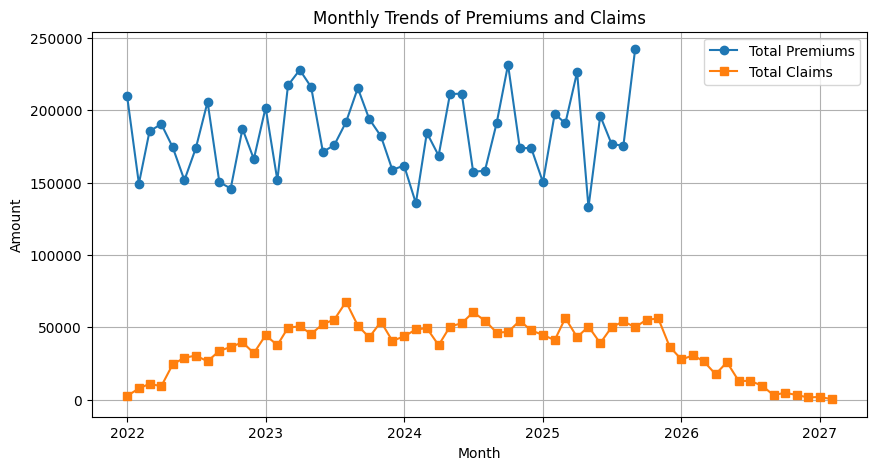

In [10]:
import matplotlib.pyplot as plt

# Step 1: Make sure date columns are in datetime format
final_model["start_date"] = pd.to_datetime(final_model["start_date"])
final_model["claim_date"] = pd.to_datetime(final_model["claim_date"])

# Step 2: Create month columns
final_model["premium_month"] = final_model["start_date"].dt.to_period("M")
final_model["claim_month"] = final_model["claim_date"].dt.to_period("M")

# Step 3: Group and sum monthly totals
monthly_premium = final_model.groupby("premium_month")["premium_amount"].sum()
monthly_claims = final_model.groupby("claim_month")["approved_amount"].sum()

# Step 4: Convert index back to datetime (for plotting)
monthly_premium.index = monthly_premium.index.to_timestamp()
monthly_claims.index = monthly_claims.index.to_timestamp()

# Step 5: Plot both trends
plt.figure(figsize=(10,5))
plt.plot(monthly_premium.index, monthly_premium.values, marker="o", label="Total Premiums")
plt.plot(monthly_claims.index, monthly_claims.values, marker="s", label="Total Claims")
plt.title("Monthly Trends of Premiums and Claims")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Step 1: Group data by customer
customer_summary = final_model.groupby("customer_id").agg({
    "premium_amount": "sum",
    "approved_amount": "sum",
    "claim_id": "count"
}).reset_index()

# Step 2: Rename columns for clarity
customer_summary = customer_summary.rename(columns={
    "premium_amount": "total_premium",
    "approved_amount": "total_claims",
    "claim_id": "num_claims"
})

# Step 3: Calculate loss ratio
customer_summary["loss_ratio"] = customer_summary["total_claims"] / customer_summary["total_premium"]

# Step 4: Identify high-risk customers
high_risk = customer_summary[
    (customer_summary["loss_ratio"] > 0.8) | 
    (customer_summary["num_claims"] > 3)
]

# Step 5: Print results
print("High-risk customers:")
print(high_risk)

print("\nNumber of high-risk customers:", high_risk.shape[0])


High-risk customers:
     customer_id  total_premium  total_claims  num_claims  loss_ratio
0              1       14115.82       4257.12          24    0.301585
1              2        2410.74        673.48           4    0.279367
2              3        2317.62        157.03           8    0.067755
3              4       12939.41       1710.00          23    0.132154
4              5       15512.92       1228.88          14    0.079217
..           ...            ...           ...         ...         ...
987          996        5274.56       1093.79           9    0.207371
988          997       14916.58        809.50          19    0.054268
989          998       19808.57       6779.73          53    0.342262
990          999        1684.62        327.72           4    0.194536
991         1000        7716.59       2451.22          18    0.317656

[889 rows x 5 columns]

Number of high-risk customers: 889


Average claim severity and frequency per region:
         region  num_policies  num_claims  total_claims_amount  \
0      Absheron           333         779            141384.00   
1          Baku           310         699            141624.67   
2         Ganja           324         685            132618.08   
3       Goychay           317         713            137007.06   
4      Khachmaz           327         735            138456.92   
5      Lankaran           371         833            147233.59   
6       Masazir           354         823            164456.89   
7   Mingachevir           298         712            146221.63   
8    Nakhchivan           360         809            151834.76   
9          Quba           366         925            187618.93   
10        Shaki           424        1032            210445.83   
11     Shamakhi           390         926            158299.52   
12      Shirvan           388         963            184382.53   
13      Sumgait           4

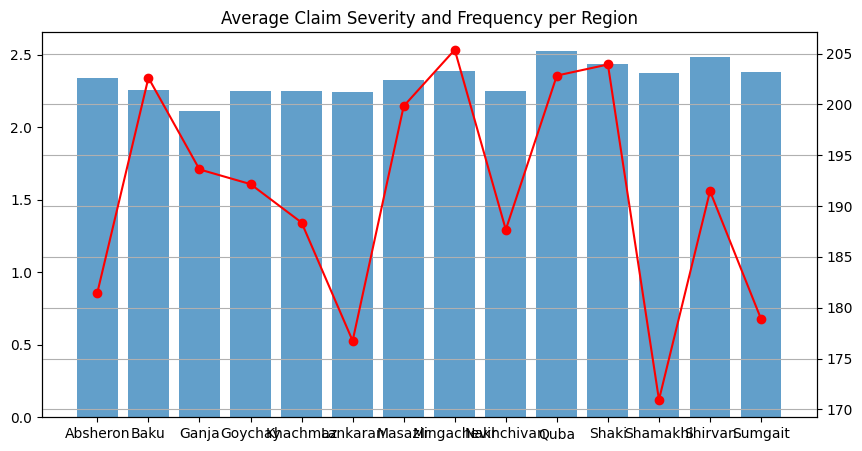

In [ ]:
# Step 1: Group by region
region_stats = final_model.groupby("region").agg({
    "policy_id": "nunique",
    "claim_id": "count",
    "approved_amount": "sum"
}).reset_index()

# Step 2: Rename columns
region_stats = region_stats.rename(columns={
    "policy_id": "num_policies",
    "claim_id": "num_claims",
    "approved_amount": "total_claims_amount"
})

# Step 3: Calculate KPI
region_stats["claim_frequency"] = region_stats["num_claims"] / region_stats["num_policies"]
region_stats["avg_claim_severity"] = region_stats["total_claims_amount"] / region_stats["num_claims"]

# Step 4: Print the table
print("Average claim severity and frequency per region:")
print(region_stats)

# Step 5: Visualize the results
plt.figure(figsize=(10,5))

# Plot claim frequency
plt.bar(region_stats["region"], region_stats["claim_frequency"], label="Claim Frequency", alpha=0.7)

# Plot claim severity on secondary axis
plt.twinx()
plt.plot(region_stats["region"], region_stats["avg_claim_severity"], color="red", marker="o", label="Avg Claim Severity")

plt.title("Average Claim Severity and Frequency per Region")
plt.xlabel("Region")
plt.grid(True)
plt.show()

Correlation matrix:
                 premium_amount  claim_amount  approved_amount  payment_amount
premium_amount         1.000000      0.453807         0.334700        0.746281
claim_amount           0.453807      1.000000         0.771135        0.340691
approved_amount        0.334700      0.771135         1.000000        0.250853
payment_amount         0.746281      0.340691         0.250853        1.000000


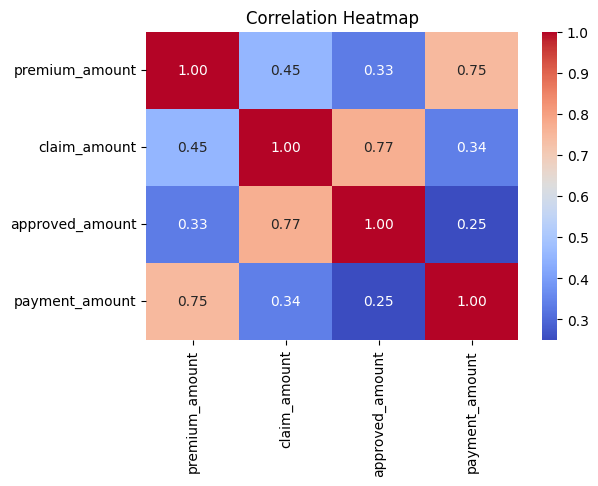

In [ ]:
import seaborn as sns
# Step 1: Select only numeric columns
corr_data = final_model[["premium_amount", "claim_amount", "approved_amount", "payment_amount"]]

# Step 2: Compute correlation matrix
corr_matrix = corr_data.corr()

# Step 3: Print the correlation values
print("Correlation matrix:")
print(corr_matrix)

# Step 4: Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Step 1: Calculate claim ratio and frequency for each customer
customer_stats = final_model.groupby("customer_id").agg({
    "policy_id": "nunique",
    "claim_id": "count",
    "approved_amount": "sum",
    "premium_amount": "sum"
}).reset_index()

# Step 2: Rename columns
customer_stats = customer_stats.rename(columns={
    "policy_id": "num_policies",
    "claim_id": "num_claims",
    "approved_amount": "total_claims",
    "premium_amount": "total_premium"
})

# Step 3: Calculate KPI
customer_stats["claim_ratio"] = customer_stats["total_claims"] / customer_stats["total_premium"]
customer_stats["claim_frequency"] = customer_stats["num_claims"] / customer_stats["num_policies"]

# Step 4: Define segmentation rules
def risk_segment(row):
    if row["claim_ratio"] > 0.8 or row["claim_frequency"] > 0.5:
        return "High Risk"
    elif row["claim_ratio"] > 0.4 or row["claim_frequency"] > 0.25:
        return "Medium Risk"
    else:
        return "Low Risk"

# Step 5: Apply segmentation
customer_stats["risk_segment"] = customer_stats.apply(risk_segment, axis=1)

# Step 6: Print the results
print("Customer segmentation buckets:")
print(customer_stats[["customer_id", "claim_ratio", "claim_frequency", "risk_segment"]].head())

Customer segmentation buckets:
   customer_id  claim_ratio  claim_frequency risk_segment
0            1     0.301585         4.000000    High Risk
1            2     0.279367         1.333333    High Risk
2            3     0.067755         2.000000    High Risk
3            4     0.132154         3.833333    High Risk
4            5     0.079217         1.555556    High Risk


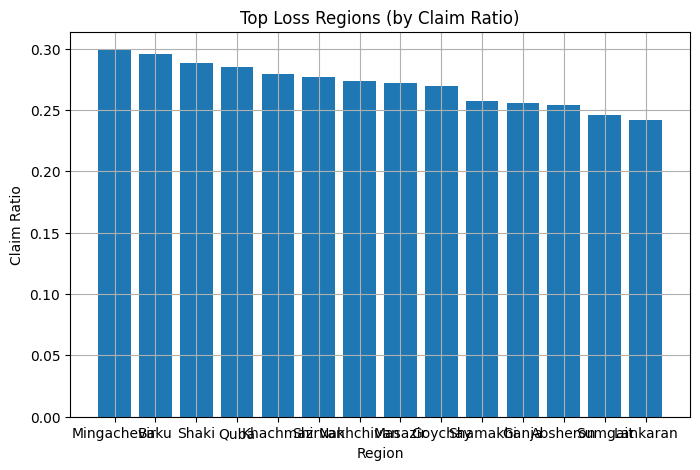

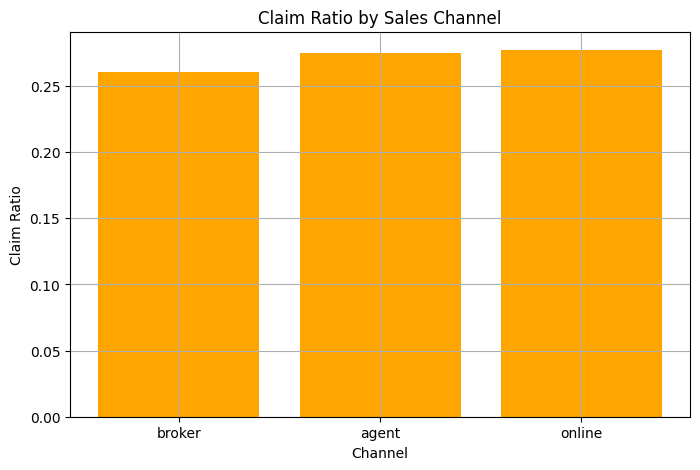

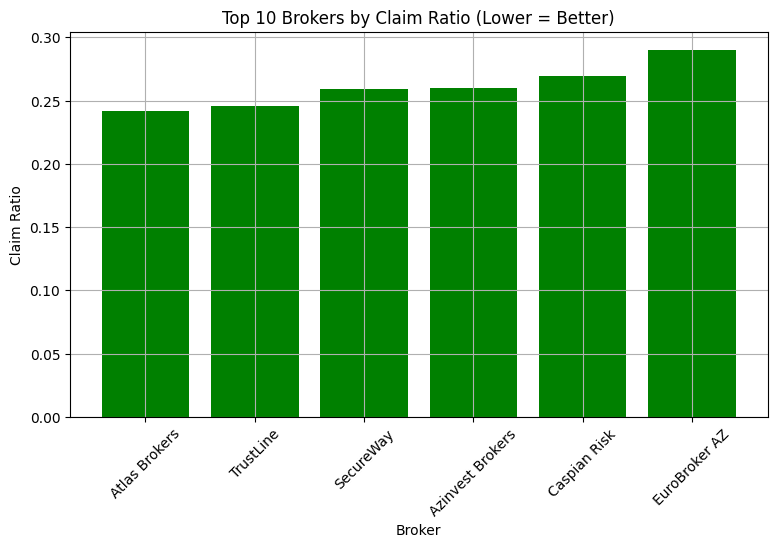

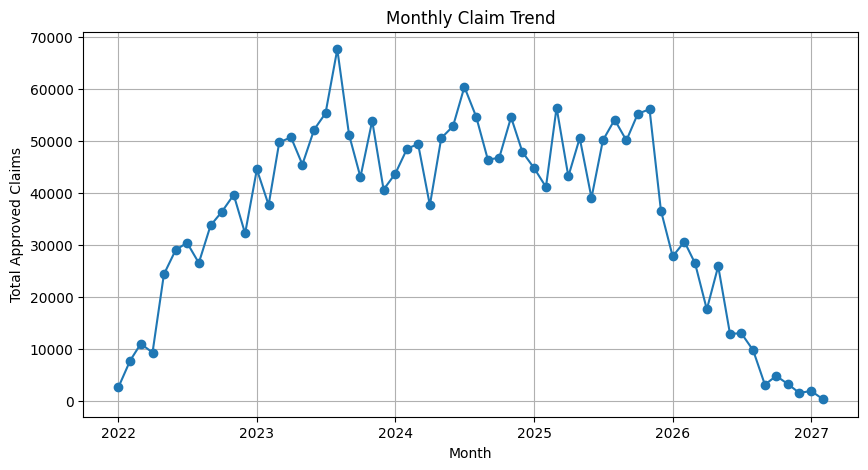

In [ ]:
#INSIGHT 1 — “Top Loss Regions”

# Calculate total claims and premiums per region
region_loss = final_model.groupby("region").agg({
    "approved_amount": "sum",
    "premium_amount": "sum"
}).reset_index()

region_loss["claim_ratio"] = region_loss["approved_amount"] / region_loss["premium_amount"]

# Sort by claim ratio
region_loss = region_loss.sort_values(by="claim_ratio", ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.bar(region_loss["region"], region_loss["claim_ratio"])
plt.title("Top Loss Regions (by Claim Ratio)")
plt.xlabel("Region")
plt.ylabel("Claim Ratio")
plt.grid(True)
plt.show()

#INSIGHT 2 — “Most Profitable Sales Channels”
channel_perf = final_model.groupby("channel").agg({
    "approved_amount": "sum",
    "premium_amount": "sum"
}).reset_index()

channel_perf["claim_ratio"] = channel_perf["approved_amount"] / channel_perf["premium_amount"]
channel_perf = channel_perf.sort_values(by="claim_ratio")

plt.figure(figsize=(8,5))
plt.bar(channel_perf["channel"], channel_perf["claim_ratio"], color="orange")
plt.title("Claim Ratio by Sales Channel")
plt.xlabel("Channel")
plt.ylabel("Claim Ratio")
plt.grid(True)
plt.show()

#INSIGHT 3 — “Broker Performance”
broker_perf = final_model.groupby("broker_name").agg({
    "approved_amount": "sum",
    "premium_amount": "sum"
}).reset_index()

broker_perf["claim_ratio"] = broker_perf["approved_amount"] / broker_perf["premium_amount"]
top_brokers = broker_perf.sort_values(by="claim_ratio").head(10)

plt.figure(figsize=(9,5))
plt.bar(top_brokers["broker_name"], top_brokers["claim_ratio"], color="green")
plt.title("Top 10 Brokers by Claim Ratio (Lower = Better)")
plt.xticks(rotation=45)
plt.xlabel("Broker")
plt.ylabel("Claim Ratio")
plt.grid(True)
plt.show()


#INSIGHT 4 — “Monthly Claims Trend”
final_model["claim_date"] = pd.to_datetime(final_model["claim_date"])
monthly_claims = final_model.groupby(final_model["claim_date"].dt.to_period("M"))["approved_amount"].sum()
monthly_claims.index = monthly_claims.index.to_timestamp()

plt.figure(figsize=(10,5))
plt.plot(monthly_claims.index, monthly_claims.values, marker="o")
plt.title("Monthly Claim Trend")
plt.xlabel("Month")
plt.ylabel("Total Approved Claims")
plt.grid(True)
plt.show()

